In [2]:
import pandas as pd
from pathlib import Path

COLUMNS = [
    "ip_mean", "ip_std", "ip_kurtosis", "ip_skewness",
    "dm_mean", "dm_std", "dm_kurtosis", "dm_skewness",
    "pulsar",
]

csv_path = Path("..") / "data" / "raw" / "HTRU_2.csv"
df = pd.read_csv(csv_path, header=None, names=COLUMNS)

print("shape:", df.shape)
print()
print("clases:")
print(df["pulsar"].value_counts())
print("proporcion positiva:", df["pulsar"].mean().round(4))
print()
print(df.describe().T[["mean", "std", "min", "max"]])


shape: (17898, 9)

clases:
pulsar
0    16259
1     1639
Name: count, dtype: int64
proporcion positiva: 0.0916

                   mean         std        min          max
ip_mean      111.079968   25.652935   5.812500   192.617188
ip_std        46.549532    6.843189  24.772042    98.778911
ip_kurtosis    0.477857    1.064040  -1.876011     8.069522
ip_skewness    1.770279    6.167913  -1.791886    68.101622
dm_mean       12.614400   29.472897   0.213211   223.392141
dm_std        26.326515   19.470572   7.370432   110.642211
dm_kurtosis    8.303556    4.506092  -3.139270    34.539844
dm_skewness  104.857709  106.514540  -1.976976  1191.000837
pulsar         0.091574    0.288432   0.000000     1.000000


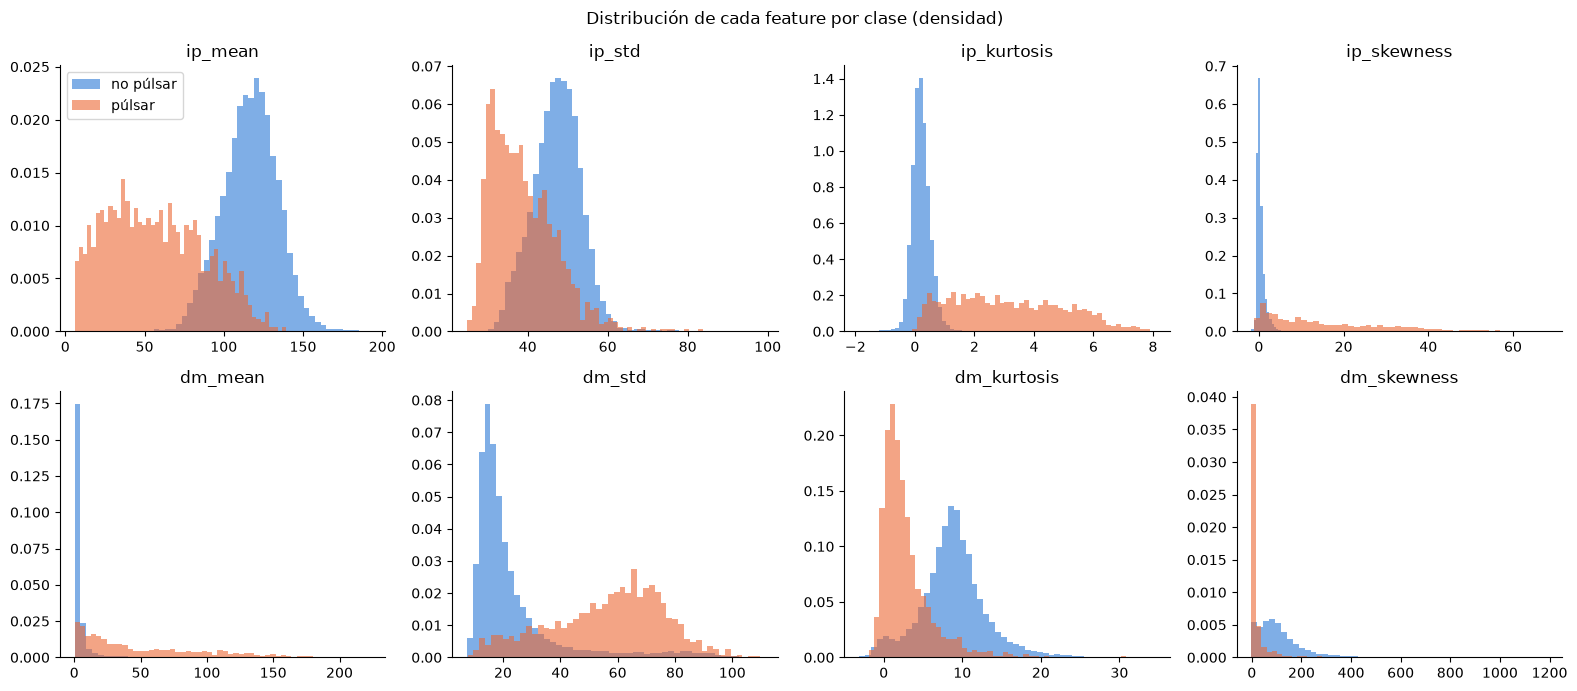

In [3]:
import matplotlib.pyplot as plt

features = COLUMNS[:-1]
colors = {0: "#2a78d6", 1: "#eb6834"}
labels = {0: "no púlsar", 1: "púlsar"}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, feat in zip(axes.flat, features):
    for cls in (0, 1):
        ax.hist(
            df.loc[df["pulsar"] == cls, feat],
            bins=50, density=True, alpha=0.6,
            color=colors[cls], label=labels[cls],
        )
    ax.set_title(feat)
    ax.spines[["top", "right"]].set_visible(False)

axes[0, 0].legend()
fig.suptitle("Distribución de cada feature por clase (densidad)")
fig.tight_layout()
plt.show()
